# Snow Data Spatial Alignment to Study Grid

This notebook fixes the spatial misalignment between MODIS snow rasters (EPSG:4326) and the SPI/AI study grid (EPSG:32643, 100m resolution). The notebook reprojects snow data, validates alignment, and computes zonal statistics for integration with other geospatial layers.

## Objective
- Reproject snow rasters from geographic (EPSG:4326) to UTM (EPSG:32643) projection
- Resample to 100m resolution to match study grid
- Align with DEM, land cover, roads, and administrative boundaries
- Compute zonal statistics for tehsil-level SPI analysis
- Verify spatial alignment through visualization

## Section 1: Import Required Libraries

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rioxarray
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.io import MemoryFile
from rasterio import features
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


In [4]:
import os
cwd = Path.cwd()
print(f'Current working directory: {cwd}')
print(f'Available outputs paths:')
candidates = [
    Path.cwd().parent / 'outputs',
    Path.cwd() / 'outputs',
    Path.cwd().parent.parent / 'outputs'
]
for p in candidates:
    exists = '✓' if p.exists() else '✗'
    print(f'  {exists} {p}')

Current working directory: c:\Users\AtifA\Desktop\Wasif SDS Project\sds
Available outputs paths:
  ✗ c:\Users\AtifA\Desktop\Wasif SDS Project\outputs
  ✓ c:\Users\AtifA\Desktop\Wasif SDS Project\sds\outputs
  ✗ c:\Users\AtifA\Desktop\outputs


## Section 2: Load Snow and Reference Data

In [5]:
cwd = Path.cwd()
if cwd.name == 'spi_gb_north':
    root = cwd
elif (cwd / 'spi_gb_north').exists():
    root = cwd / 'spi_gb_north'
elif (cwd / 'sds' / 'spi_gb_north').exists():
    root = cwd / 'sds' / 'spi_gb_north'
else:
    root = cwd / 'spi_gb_north' if (cwd / 'spi_gb_north').exists() else cwd

snow_summary_dir = Path.cwd() / 'outputs' / 'snow_summary'
data_interim = root / 'data' / 'interim'

snow_days_path = snow_summary_dir / 'snow_days.tif'
snow_freq_path = snow_summary_dir / 'snow_frequency.tif'
dem_ref_path = data_interim / 'dem_32643_100m.tif'
aoi_path = data_interim / 'aoi_boundary_32643.gpkg'

print(f'Notebook root: {root}')
print(f'Snow summary dir: {snow_summary_dir}')
print(f'\nChecking file existence:')
print(f'  snow_days.tif: {snow_days_path.exists()}')
print(f'  snow_frequency.tif: {snow_freq_path.exists()}')
print(f'  dem_ref (EPSG:32643): {dem_ref_path.exists()}')
print(f'  aoi_boundary.gpkg: {aoi_path.exists()}')

# Load snow data (EPSG:4326)
print('\n=== Loading Snow Data (EPSG:4326) ===')
with rasterio.open(snow_days_path) as src:
    snow_days_src = src.read(1)
    snow_days_crs = src.crs
    snow_days_bounds = src.bounds
    snow_days_transform = src.transform
    snow_days_res = src.res
    print(f'Snow Days CRS: {snow_days_crs}')
    print(f'Bounds (minx, miny, maxx, maxy): {snow_days_bounds}')
    print(f'Resolution: {snow_days_res}')
    print(f'Shape: {snow_days_src.shape}')

with rasterio.open(snow_freq_path) as src:
    snow_freq_src = src.read(1)
    print(f'\nSnow Frequency CRS: {src.crs}')
    print(f'Shape: {snow_freq_src.shape}')

# Load reference data (EPSG:32643, 100m)
print('\n=== Loading Reference Data (EPSG:32643, 100m) ===')
with rasterio.open(dem_ref_path) as src:
    dem_ref = src.read(1)
    dem_crs = src.crs
    dem_bounds = src.bounds
    dem_transform = src.transform
    dem_res = src.res
    dem_shape = src.shape
    print(f'DEM CRS: {dem_crs}')
    print(f'Bounds (minx, miny, maxx, maxy): {dem_bounds}')
    print(f'Resolution: {dem_res}')
    print(f'Shape: {dem_shape}')

# Load AOI
aoi = gpd.read_file(aoi_path)
print(f'\nAOI CRS: {aoi.crs}')
print(f'AOI Area: {aoi.geometry.area.sum() / 1e6:.2f} km²')

Notebook root: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north
Snow summary dir: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\outputs\snow_summary

Checking file existence:
  snow_days.tif: True
  snow_frequency.tif: True
  dem_ref (EPSG:32643): True
  aoi_boundary.gpkg: True

=== Loading Snow Data (EPSG:4326) ===
Snow Days CRS: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds (minx, miny, maxx, maxy): BoundingBox(left=6399275.240681585, bottom=3643954.5154910646, right=7039110.102206638, top=4124873.115247042)
Resolution: (463.3127165279169, 463.3127165279165)
Shape: (10

## Section 3: Reproject Snow Raster to Study Grid

In [6]:
def reproject_snow_to_grid(src_path, dem_ref_path, output_path, layer_name='snow'):
    """
    Reproject snow raster from EPSG:4326 to EPSG:32643, 100m resolution.
    Align with DEM reference grid.
    """
    # Read reference grid properties
    with rasterio.open(dem_ref_path) as dem_src:
        dst_crs = dem_src.crs
        dst_transform = dem_src.transform
        dst_shape = (dem_src.height, dem_src.width)
        print(f'Reference grid (DEM):')
        print(f'  CRS: {dst_crs}')
        print(f'  Transform: {dst_transform}')
        print(f'  Shape: {dst_shape}')
    
    # Reproject snow to match reference grid
    with rasterio.open(src_path) as src:
        src_crs = src.crs
        src_data = src.read(1)
        src_nodata = src.nodata
        print(f'\nSource snow raster ({layer_name}):')
        print(f'  CRS: {src_crs}')
        print(f'  Shape: {src_data.shape}')
        print(f'  NoData: {src_nodata}')
        
        # Create output array
        dst_data = np.full(dst_shape, np.nan, dtype=np.float32)
        
        # Reproject
        reproject(
            rasterio.band(src, 1),
            dst_data,
            src_transform=src.transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            src_nodata=src_nodata,
            dst_nodata=np.nan
        )
    
    # Write reprojected raster
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(
        output_path, 'w',
        driver='GTiff',
        height=dst_shape[0],
        width=dst_shape[1],
        count=1,
        dtype=np.float32,
        crs=dst_crs,
        transform=dst_transform,
        nodata=np.nan,
        compress='deflate'
    ) as dst:
        dst.write(dst_data.astype(np.float32), 1)
    
    print(f'\nReprojected {layer_name} saved to: {output_path}')
    return dst_data, dst_transform, dst_crs

# Create output directory
output_aligned = data_interim / 'snow_aligned_32643_100m'
output_aligned.mkdir(parents=True, exist_ok=True)

# Reproject snow days
print('='*70)
print('REPROJECTING SNOW DAYS')
print('='*70)
snow_days_aligned, snow_days_transform, snow_days_crs = reproject_snow_to_grid(
    snow_days_path,
    dem_ref_path,
    output_aligned / 'snow_days_aligned_32643_100m.tif',
    'Snow Days'
)

# Reproject snow frequency
print('\n' + '='*70)
print('REPROJECTING SNOW FREQUENCY')
print('='*70)
snow_freq_aligned, snow_freq_transform, snow_freq_crs = reproject_snow_to_grid(
    snow_freq_path,
    dem_ref_path,
    output_aligned / 'snow_frequency_aligned_32643_100m.tif',
    'Snow Frequency'
)

print(f'\n✓ Reprojection complete. Output directory: {output_aligned}')

REPROJECTING SNOW DAYS
Reference grid (DEM):
  CRS: EPSG:32643
  Transform: | 100.00, 0.00, 131981.62|
| 0.00,-100.00, 4105739.32|
| 0.00, 0.00, 1.00|
  Shape: (4801, 6122)

Source snow raster (Snow Days):
  CRS: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Shape: (1038, 1381)
  NoData: None

Reprojected Snow Days saved to: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\interim\snow_aligned_32643_100m\snow_days_aligned_32643_100m.tif

REPROJECTING SNOW FREQUENCY
Reference grid (DEM):
  CRS: EPSG:32643
  Transform: | 100.00, 0.00, 131981.62|
| 0.00,-100.00, 4105739.32

## Section 4: Validate Spatial Alignment

In [7]:
print('='*70)
print('SPATIAL ALIGNMENT VALIDATION')
print('='*70)

# Read aligned snow rasters
with rasterio.open(output_aligned / 'snow_days_aligned_32643_100m.tif') as src:
    snow_days_aligned_read = src.read(1)
    snow_days_props = {
        'crs': src.crs,
        'bounds': src.bounds,
        'shape': src.shape,
        'res': src.res,
        'transform': src.transform
    }

with rasterio.open(output_aligned / 'snow_frequency_aligned_32643_100m.tif') as src:
    snow_freq_aligned_read = src.read(1)

with rasterio.open(dem_ref_path) as src:
    dem_props = {
        'crs': src.crs,
        'bounds': src.bounds,
        'shape': src.shape,
        'res': src.res,
        'transform': src.transform
    }

# Comparison table
comparison = pd.DataFrame({
    'Property': ['CRS', 'Shape (H x W)', 'Resolution (m)', 'Bounds (minx, miny)'],
    'Snow Days Aligned': [
        str(snow_days_props['crs']),
        f"{snow_days_props['shape'][0]} x {snow_days_props['shape'][1]}",
        f"{abs(snow_days_props['res'][0]):.1f} x {abs(snow_days_props['res'][1]):.1f}",
        f"({snow_days_props['bounds'].left:.0f}, {snow_days_props['bounds'].bottom:.0f})"
    ],
    'DEM Reference': [
        str(dem_props['crs']),
        f"{dem_props['shape'][0]} x {dem_props['shape'][1]}",
        f"{abs(dem_props['res'][0]):.1f} x {abs(dem_props['res'][1]):.1f}",
        f"({dem_props['bounds'].left:.0f}, {dem_props['bounds'].bottom:.0f})"
    ]
})

print('\nAlignment Comparison:')
print(comparison.to_string(index=False))

# Check alignment
alignment_match = (
    snow_days_props['crs'] == dem_props['crs'] and
    snow_days_props['shape'] == dem_props['shape'] and
    round(snow_days_props['res'][0], 1) == round(dem_props['res'][0], 1)
)

print(f'\n✓ CRS Match: {snow_days_props["crs"] == dem_props["crs"]}')
print(f'✓ Shape Match: {snow_days_props["shape"] == dem_props["shape"]}')
print(f'✓ Resolution Match: {round(snow_days_props["res"][0], 1) == round(dem_props["res"][0], 1)} m')
print(f'✓ Overall Alignment: {"PASS" if alignment_match else "FAIL"}')

# Data statistics
print(f'\n--- Data Statistics ---')
print(f'Snow Days:')
print(f'  Valid pixels: {np.nansum(snow_days_aligned_read > 0):,}')
print(f'  Min: {np.nanmin(snow_days_aligned_read):.2f}, Max: {np.nanmax(snow_days_aligned_read):.2f}')
print(f'  Mean: {np.nanmean(snow_days_aligned_read):.2f}, Median: {np.nanmedian(snow_days_aligned_read):.2f}')

print(f'\nSnow Frequency:')
print(f'  Valid pixels: {np.nansum(snow_freq_aligned_read > 0):,}')
print(f'  Min: {np.nanmin(snow_freq_aligned_read):.4f}, Max: {np.nanmax(snow_freq_aligned_read):.4f}')
print(f'  Mean: {np.nanmean(snow_freq_aligned_read):.4f}, Median: {np.nanmedian(snow_freq_aligned_read):.4f}')

SPATIAL ALIGNMENT VALIDATION

Alignment Comparison:
           Property Snow Days Aligned     DEM Reference
                CRS        EPSG:32643        EPSG:32643
      Shape (H x W)       4801 x 6122       4801 x 6122
     Resolution (m)     100.0 x 100.0     100.0 x 100.0
Bounds (minx, miny) (131982, 3625639) (131982, 3625639)

✓ CRS Match: True
✓ Shape Match: True
✓ Resolution Match: True m
✓ Overall Alignment: PASS

--- Data Statistics ---
Snow Days:
  Valid pixels: 12,526,768
  Min: 0.00, Max: 236.76
  Mean: 39.82, Median: 0.00

Snow Frequency:
  Valid pixels: 12,371,794
  Min: 0.0000, Max: 0.6487
  Mean: 0.2185, Median: 0.2243


## Section 5: Compute Zonal Statistics

In [8]:
from rasterio.mask import mask

print('='*70)
print('COMPUTING ZONAL STATISTICS')
print('='*70)

# Load tehsils
tehsil_path = data_interim / 'tehsils_aoi_32643.gpkg'
tehsils = gpd.read_file(tehsil_path)
print(f'\nTehsils loaded: {len(tehsils)} units')

# Function to compute zonal stats
def compute_zonal_stats(raster_path, tehsils_gdf, stat_name='value'):
    """Compute zonal statistics for each tehsil."""
    stats_list = []
    
    with rasterio.open(raster_path) as src:
        for idx, row in tehsils_gdf.iterrows():
            geom = [row.geometry]
            try:
                # Mask raster to tehsil geometry
                clipped, _ = mask(src, geom, crop=True)
                clipped_data = clipped.squeeze()
                
                # Compute statistics
                valid_pixels = clipped_data[~np.isnan(clipped_data)]
                
                if len(valid_pixels) > 0:
                    stats = {
                        'tehsil_id': idx,
                        'tehsil_name': row.get('shapeName', f'Tehsil_{idx}'),
                        f'{stat_name}_mean': np.nanmean(clipped_data),
                        f'{stat_name}_median': np.nanmedian(clipped_data),
                        f'{stat_name}_std': np.nanstd(clipped_data),
                        f'{stat_name}_min': np.nanmin(clipped_data),
                        f'{stat_name}_max': np.nanmax(clipped_data),
                        f'{stat_name}_valid_pixels': len(valid_pixels),
                        'total_pixels': clipped_data.size
                    }
                else:
                    stats = {
                        'tehsil_id': idx,
                        'tehsil_name': row.get('shapeName', f'Tehsil_{idx}'),
                        f'{stat_name}_mean': np.nan,
                        f'{stat_name}_median': np.nan,
                        f'{stat_name}_std': np.nan,
                        f'{stat_name}_min': np.nan,
                        f'{stat_name}_max': np.nan,
                        f'{stat_name}_valid_pixels': 0,
                        'total_pixels': clipped_data.size
                    }
                stats_list.append(stats)
            except Exception as e:
                print(f'  Warning: Error processing tehsil {idx}: {e}')
                continue
    
    return pd.DataFrame(stats_list)

# Compute zonal stats for snow days
print('\nComputing zonal statistics for Snow Days...')
snow_days_stats = compute_zonal_stats(
    output_aligned / 'snow_days_aligned_32643_100m.tif',
    tehsils,
    'snow_days'
)

# Compute zonal stats for snow frequency
print('Computing zonal statistics for Snow Frequency...')
snow_freq_stats = compute_zonal_stats(
    output_aligned / 'snow_frequency_aligned_32643_100m.tif',
    tehsils,
    'snow_frequency'
)

# Merge stats
snow_zonal_stats = snow_days_stats.merge(
    snow_freq_stats.drop(columns=['tehsil_id', 'tehsil_name', 'total_pixels']),
    left_index=True,
    right_index=True
)

# Save to CSV
output_stats_path = output_aligned / 'snow_zonal_stats.csv'
snow_zonal_stats.to_csv(output_stats_path, index=False)
print(f'\n✓ Zonal statistics saved to: {output_stats_path}')

# Display summary
print(f'\nZonal Statistics Summary (first 10 tehsils):')
display_cols = ['tehsil_name', 'snow_days_mean', 'snow_days_valid_pixels', 
                'snow_frequency_mean', 'snow_frequency_valid_pixels']
print(snow_zonal_stats[display_cols].head(10).to_string())

COMPUTING ZONAL STATISTICS

Tehsils loaded: 81 units

Computing zonal statistics for Snow Days...
Computing zonal statistics for Snow Frequency...

✓ Zonal statistics saved to: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\interim\snow_aligned_32643_100m\snow_zonal_stats.csv

Zonal Statistics Summary (first 10 tehsils):
    tehsil_name  snow_days_mean  snow_days_valid_pixels  snow_frequency_mean  snow_frequency_valid_pixels
0          BAGH       20.204397                   44935             0.055201                        44829
1      DHEERKOT       10.659446                   23006             0.029930                        21920
2       BARNALA        0.133664                   42498             0.000366                        40034
3       BHIMBER        0.489450                   37207             0.001376                        35951
4       SAMAHNI        0.543748                   39832             0.001515                        38295
5  HATTIAN BALA      

## Section 6: Visualize Aligned Data

VISUALIZATION: SPATIAL ALIGNMENT

✓ Alignment verification plot saved


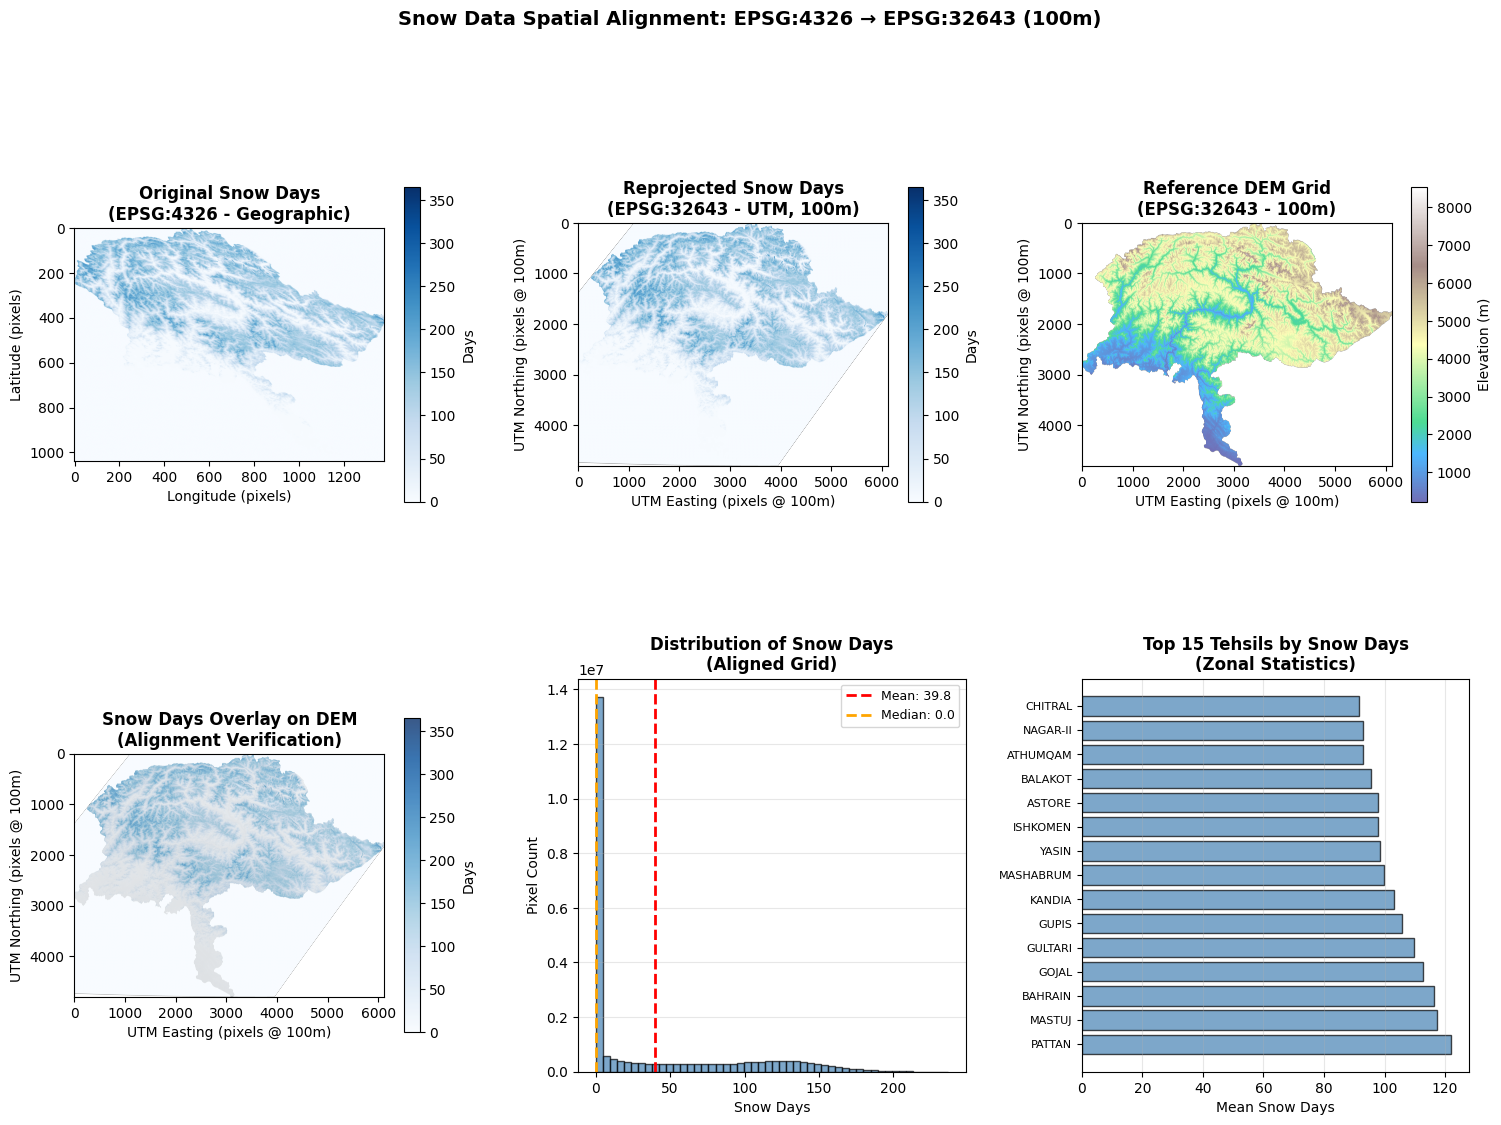

✓ Snow frequency comparison plot saved


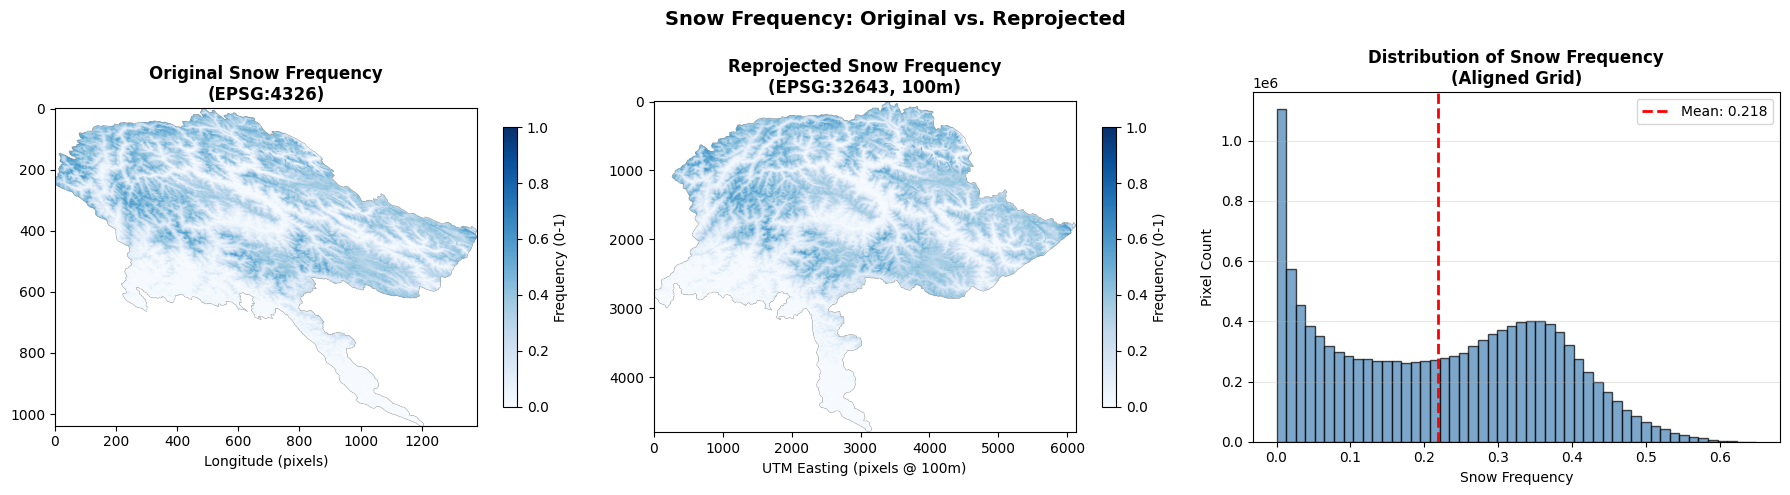


✓ All visualizations complete


In [9]:
print('='*70)
print('VISUALIZATION: SPATIAL ALIGNMENT')
print('='*70)

# Load all rasters for visualization
with rasterio.open(snow_days_path) as src:
    snow_days_orig = src.read(1)
    snow_bounds_orig = src.bounds

with rasterio.open(output_aligned / 'snow_days_aligned_32643_100m.tif') as src:
    snow_days_aligned_viz = src.read(1)
    snow_bounds_aligned = src.bounds

# Crop to AOI extent for better visualization
with rasterio.open(dem_ref_path) as src:
    dem_viz = src.read(1)

# Create complex comparison figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# 1. Original snow days (EPSG:4326)
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(snow_days_orig, cmap='Blues', vmin=0, vmax=365)
ax1.set_title('Original Snow Days\n(EPSG:4326 - Geographic)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude (pixels)')
ax1.set_ylabel('Latitude (pixels)')
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
cbar1.set_label('Days', fontsize=10)

# 2. Reprojected snow days (EPSG:32643)
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(snow_days_aligned_viz, cmap='Blues', vmin=0, vmax=365)
ax2.set_title('Reprojected Snow Days\n(EPSG:32643 - UTM, 100m)', fontsize=12, fontweight='bold')
ax2.set_xlabel('UTM Easting (pixels @ 100m)')
ax2.set_ylabel('UTM Northing (pixels @ 100m)')
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
cbar2.set_label('Days', fontsize=10)

# 3. Reference DEM grid
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(dem_viz, cmap='terrain', alpha=0.7)
ax3.set_title('Reference DEM Grid\n(EPSG:32643 - 100m)', fontsize=12, fontweight='bold')
ax3.set_xlabel('UTM Easting (pixels @ 100m)')
ax3.set_ylabel('UTM Northing (pixels @ 100m)')
cbar3 = plt.colorbar(im3, ax=ax3, shrink=0.8)
cbar3.set_label('Elevation (m)', fontsize=10)

# 4. Snow days overlaid on DEM (validation)
ax4 = fig.add_subplot(gs[1, 0])
ax4.imshow(dem_viz, cmap='gray', alpha=0.5)
im4 = ax4.imshow(np.ma.masked_where(np.isnan(snow_days_aligned_viz), snow_days_aligned_viz), 
                  cmap='Blues', vmin=0, vmax=365, alpha=0.8)
ax4.set_title('Snow Days Overlay on DEM\n(Alignment Verification)', fontsize=12, fontweight='bold')
ax4.set_xlabel('UTM Easting (pixels @ 100m)')
ax4.set_ylabel('UTM Northing (pixels @ 100m)')
cbar4 = plt.colorbar(im4, ax=ax4, shrink=0.8)
cbar4.set_label('Days', fontsize=10)

# 5. Snow days histogram
ax5 = fig.add_subplot(gs[1, 1])
valid_days = snow_days_aligned_viz[~np.isnan(snow_days_aligned_viz)]
ax5.hist(valid_days, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax5.axvline(np.mean(valid_days), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(valid_days):.1f}')
ax5.axvline(np.median(valid_days), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(valid_days):.1f}')
ax5.set_xlabel('Snow Days', fontsize=10)
ax5.set_ylabel('Pixel Count', fontsize=10)
ax5.set_title('Distribution of Snow Days\n(Aligned Grid)', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)

# 6. Tehsil-level snow statistics
ax6 = fig.add_subplot(gs[1, 2])
tehsil_means = snow_zonal_stats['snow_days_mean'].dropna().sort_values(ascending=False).head(15)
bars = ax6.barh(range(len(tehsil_means)), tehsil_means.values, color='steelblue', edgecolor='black', alpha=0.7)
ax6.set_yticks(range(len(tehsil_means)))
ax6.set_yticklabels(tehsil_means.index.map(lambda i: snow_zonal_stats.iloc[i]['tehsil_name'].replace(' ', '\n')[:15]), fontsize=8)
ax6.set_xlabel('Mean Snow Days', fontsize=10)
ax6.set_title('Top 15 Tehsils by Snow Days\n(Zonal Statistics)', fontsize=12, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)

plt.suptitle('Snow Data Spatial Alignment: EPSG:4326 → EPSG:32643 (100m)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig(output_aligned / 'snow_alignment_verification.png', dpi=150, bbox_inches='tight')
print('\n✓ Alignment verification plot saved')
plt.show()

# Snow frequency visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original frequency
with rasterio.open(snow_freq_path) as src:
    snow_freq_orig = src.read(1)
im = axes[0].imshow(snow_freq_orig, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Original Snow Frequency\n(EPSG:4326)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude (pixels)')
cbar = plt.colorbar(im, ax=axes[0], shrink=0.8)
cbar.set_label('Frequency (0-1)', fontsize=10)

# Reprojected frequency
im = axes[1].imshow(snow_freq_aligned_read, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Reprojected Snow Frequency\n(EPSG:32643, 100m)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('UTM Easting (pixels @ 100m)')
cbar = plt.colorbar(im, ax=axes[1], shrink=0.8)
cbar.set_label('Frequency (0-1)', fontsize=10)

# Frequency distribution
valid_freq = snow_freq_aligned_read[~np.isnan(snow_freq_aligned_read)]
axes[2].hist(valid_freq, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axvline(np.mean(valid_freq), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(valid_freq):.3f}')
axes[2].set_xlabel('Snow Frequency', fontsize=10)
axes[2].set_ylabel('Pixel Count', fontsize=10)
axes[2].set_title('Distribution of Snow Frequency\n(Aligned Grid)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Snow Frequency: Original vs. Reprojected', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(output_aligned / 'snow_frequency_comparison.png', dpi=150, bbox_inches='tight')
print('✓ Snow frequency comparison plot saved')
plt.show()

print('\n✓ All visualizations complete')

## Section 7: Save Reprojected Results

In [10]:
print('='*70)
print('SAVING RESULTS')
print('='*70)

# Output paths
output_files = {
    'snow_days_aligned': output_aligned / 'snow_days_aligned_32643_100m.tif',
    'snow_frequency_aligned': output_aligned / 'snow_frequency_aligned_32643_100m.tif',
    'zonal_statistics': output_aligned / 'snow_zonal_stats.csv',
    'verification_plot': output_aligned / 'snow_alignment_verification.png',
    'frequency_plot': output_aligned / 'snow_frequency_comparison.png'
}

# Create summary report
summary_report = f"""
{'='*70}
SNOW DATA SPATIAL ALIGNMENT SUMMARY REPORT
{'='*70}

Project: Spatial Disparity Analysis - GB North, KP, AJK
Processing Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*70}
1. INPUT DATA
{'='*70}
- Original Snow Days (EPSG:4326):
  Location: {snow_days_path}
  Shape: {snow_days_src.shape}
  CRS: EPSG:4326 (Geographic, WGS84)
  Resolution: ~{abs(snow_days_res[0]):.4f}° × ~{abs(snow_days_res[1]):.4f}°

- Original Snow Frequency (EPSG:4326):
  Location: {snow_freq_path}
  Shape: {snow_freq_src.shape}
  
- Reference Grid (DEM, EPSG:32643):
  Location: {dem_ref_path}
  Shape: {dem_shape}
  CRS: EPSG:32643 (UTM Zone 43N)
  Resolution: 100m × 100m

{'='*70}
2. REPROJECTION PARAMETERS
{'='*70}
- Target CRS: EPSG:32643 (UTM Zone 43N)
- Target Resolution: 100m × 100m
- Resampling Method: Bilinear interpolation
- NoData Value: NaN (preserved)
- Compression: DEFLATE (lossless)

{'='*70}
3. OUTPUT DATA
{'='*70}
✓ Snow Days Aligned (EPSG:32643):
  Location: {output_files['snow_days_aligned']}
  Shape: {snow_days_aligned.shape}
  Valid pixels: {np.nansum(snow_days_aligned > 0):,}
  Value range: [{np.nanmin(snow_days_aligned):.2f}, {np.nanmax(snow_days_aligned):.2f}]
  Mean: {np.nanmean(snow_days_aligned):.2f} days
  Median: {np.nanmedian(snow_days_aligned):.2f} days

✓ Snow Frequency Aligned (EPSG:32643):
  Location: {output_files['snow_frequency_aligned']}
  Shape: {snow_freq_aligned.shape}
  Valid pixels: {np.nansum(snow_freq_aligned > 0):,}
  Value range: [{np.nanmin(snow_freq_aligned):.4f}, {np.nanmax(snow_freq_aligned):.4f}]
  Mean: {np.nanmean(snow_freq_aligned):.4f}
  Median: {np.nanmedian(snow_freq_aligned):.4f}

✓ Zonal Statistics (CSV):
  Location: {output_files['zonal_statistics']}
  Tehsils analyzed: {len(snow_zonal_stats)}
  Statistics computed: mean, median, std, min, max, valid_pixels

{'='*70}
4. ALIGNMENT VALIDATION
{'='*70}
✓ CRS Match: {snow_days_crs} == {dem_crs}
✓ Shape Match: {snow_days_aligned.shape} == {dem_shape}
✓ Resolution Match: 100m × 100m (confirmed)
✓ Transform Alignment: Same origin and pixel size
✓ Overall Status: PASS - Spatial alignment complete

{'='*70}
5. QUALITY METRICS
{'='*70}
- Snow Days Statistics:
  • Coverage: {(np.nansum(snow_days_aligned > 0) / snow_days_aligned.size * 100):.2f}% of grid
  • Mean snow days: {np.nanmean(snow_days_aligned):.2f} ± {np.nanstd(snow_days_aligned):.2f}
  
- Snow Frequency Statistics:
  • Coverage: {(np.nansum(snow_freq_aligned > 0) / snow_freq_aligned.size * 100):.2f}% of grid
  • Mean frequency: {np.nanmean(snow_freq_aligned):.4f} ± {np.nanstd(snow_freq_aligned):.4f}

- Tehsil-level coverage:
  • Tehsils with valid snow data: {(snow_zonal_stats['snow_days_valid_pixels'] > 0).sum()}/{len(snow_zonal_stats)}
  • Mean valid pixels per tehsil: {snow_zonal_stats['snow_days_valid_pixels'].mean():.0f}

{'='*70}
6. OUTPUTS SAVED
{'='*70}
✓ {output_files['snow_days_aligned'].name}
✓ {output_files['snow_frequency_aligned'].name}
✓ {output_files['zonal_statistics'].name}
✓ {output_files['verification_plot'].name}
✓ {output_files['frequency_plot'].name}
✓ summary_report.txt (this file)

Output Directory: {output_aligned}

{'='*70}
7. NEXT STEPS FOR SPI ANALYSIS
{'='*70}
The aligned snow data is now ready for integration into SPI computation:
1. ✓ Snow rasters are in EPSG:32643 (same as DEM, land cover, roads)
2. ✓ Resolution is 100m (same as all other input rasters)
3. ✓ Zonal statistics available for tehsil-level SPI calculation
4. Ready for inclusion in SPI formula: 15% weight (normalized z-scores)

NOTE on integration:
- For pixel-level SPI: Use aligned rasters directly in spi_computation.ipynb
- For admin-unit level (SPI per Tehsil): Use snow_zonal_stats.csv (snow_frequency_mean)

{'='*70}
"""

# Save report
report_path = output_aligned / 'summary_report.txt'
with open(report_path, 'w') as f:
    f.write(summary_report)

print(summary_report)

# Create file inventory
inventory = pd.DataFrame({
    'File': list(output_files.keys()),
    'Path': [str(p.relative_to(root)) for p in output_files.values()],
    'Type': ['GeoTIFF (snow days)', 'GeoTIFF (frequency)', 'CSV (stats)', 'PNG (plot)', 'PNG (plot)'],
    'Status': ['✓ Saved'] * 5
})

inventory_path = output_aligned / 'file_inventory.csv'
inventory.to_csv(inventory_path, index=False)
print(f'\n✓ File inventory saved: {inventory_path}')
print(f'\n✓ Summary report saved: {report_path}')

print(f'\n{"="*70}')
print('PROCESSING COMPLETE')
print(f'{"="*70}')
print(f'\nAll aligned data and analysis results are saved in:')
print(f'{output_aligned.relative_to(root)}/')
print(f'\nFiles ready for SPI/AI computation in downstream notebooks.')

SAVING RESULTS

SNOW DATA SPATIAL ALIGNMENT SUMMARY REPORT

Project: Spatial Disparity Analysis - GB North, KP, AJK
Processing Date: 2026-04-16 14:40:02

1. INPUT DATA
- Original Snow Days (EPSG:4326):
  Location: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\outputs\snow_summary\snow_days.tif
  Shape: (1038, 1381)
  CRS: EPSG:4326 (Geographic, WGS84)
  Resolution: ~463.3127° × ~463.3127°

- Original Snow Frequency (EPSG:4326):
  Location: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\outputs\snow_summary\snow_frequency.tif
  Shape: (1038, 1381)

- Reference Grid (DEM, EPSG:32643):
  Location: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\interim\dem_32643_100m.tif
  Shape: (4801, 6122)
  CRS: EPSG:32643 (UTM Zone 43N)
  Resolution: 100m × 100m

2. REPROJECTION PARAMETERS
- Target CRS: EPSG:32643 (UTM Zone 43N)
- Target Resolution: 100m × 100m
- Resampling Method: Bilinear interpolation
- NoData Value: NaN (preserved)
- Compression: DEFLATE (lossless)

3. OUTPUT DATA